In [1]:
# Installs kept from Parag's Colab setup -- commented out for local runs
# (pennylane 0.45 is already in the local miniconda; no GPU on this machine).
# !pip install pennylane --quiet
# !pip install pennylane-lightning[gpu] --quiet

In [2]:
import matplotlib.pyplot as plt
import pennylane as qml
from pennylane import numpy as np
import math

In [3]:
num_qubits = 14
num_layers = 6
dev = qml.device("lightning.qubit", wires=num_qubits)  # local CPU (Parag used lightning.gpu on Colab)

coeffs = []
observables = []
for i in range(num_qubits - 1):
    coeffs.append(-1.0)
    observables.append(qml.PauliZ(i) @ qml.PauliZ(i+1))
for i in range(num_qubits):
    coeffs.append(-1.0)
    observables.append(qml.PauliX(i))
H = qml.Hamiltonian(coeffs, observables)

def ansatz(params):
    for layer in range(num_layers):
        for q in range(num_qubits):
            qml.RX(params[layer, q, 0], wires=q)
            qml.RY(params[layer, q, 1], wires=q)
        for q in range(num_qubits - 1):
            qml.CNOT(wires=[q, q+1])

@qml.qnode(dev)
def cost_fn(params):
    ansatz(params)
    return qml.expval(H)

@qml.qnode(dev)
def var_fn(params):
    ansatz(params)
    return qml.var(H)

# Note: Eigendecomposition on 10 qubits (1024x1024) might take a moment.
# eigvals = np.linalg.eigvalsh(qml.matrix(H, wire_order=range(num_qubits)))
# delta = eigvals[1] - eigvals[0]

np.random.seed(42)
init_params = np.random.normal(0, np.pi, (num_layers, num_qubits, 2), requires_grad=True)
grad_fn = qml.grad(cost_fn)


In [4]:
params_hybrid = init_params.copy()
hybrid_costs = []
prev_cost = np.inf
mode = "weinstein"
fixed_lr = 0.1

print("--- Starting Hybrid Run ---")
for step in range(50):
    cost = cost_fn(params_hybrid)
    hybrid_costs.append(cost)

    var = var_fn(params_hybrid)
    std = np.sqrt(var)
    grad = grad_fn(params_hybrid)
    grad_norm_sq = np.sum(grad**2)

    if mode == "weinstein" and cost > prev_cost:
        print(f"Step {step:03d}: Loss increased! Switching to standard SGD.")
        mode = "sgd"

    # elif mode in ["weinstein", "sgd"] and std < delta:
    #     print(f"Step {step:03d}: std < delta. Switching to Temple phase.")
    #     mode = "temple"

    print(f"Step {step:03d}: Cost = {cost:.6f} | Mode = {mode}")

    if mode == "weinstein":
        lr = std / (grad_norm_sq + 1e-8)
    elif mode == "temple":
        lr = (var / delta) / (grad_norm_sq + 1e-8)
    else:
        lr = fixed_lr

    params_hybrid = params_hybrid - lr * grad
    prev_cost = cost


--- Starting Hybrid Run ---


Step 000: Cost = -0.203811 | Mode = weinstein


Step 001: Cost = -1.804330 | Mode = weinstein


Step 002: Cost = -3.665741 | Mode = weinstein


Step 003: Cost = -4.599586 | Mode = weinstein


...

Step 045: Cost = -14.782485 | Mode = sgd


Step 046: Cost = -14.860149 | Mode = sgd


Step 047: Cost = -14.935549 | Mode = sgd


Step 048: Cost = -15.008833 | Mode = sgd


Step 049: Cost = -15.080067 | Mode = sgd


In [5]:

# --- 2. Pure SGD Run ---
params_sgd = init_params.copy()
sgd_costs = []

print("\n--- Starting Pure SGD Run ---")
for step in range(50):
    cost = cost_fn(params_sgd)
    sgd_costs.append(cost)
    grad = grad_fn(params_sgd)

    if step%10 == 0:
        print(f"Step {step:03d}: Cost = {cost:.6f}")
    params_sgd = params_sgd - fixed_lr * grad


--- Starting Pure SGD Run ---


Step 000: Cost = -0.203811


Step 010: Cost = -2.159008


Step 020: Cost = -4.533443


Step 030: Cost = -7.969767


Step 040: Cost = -11.824285


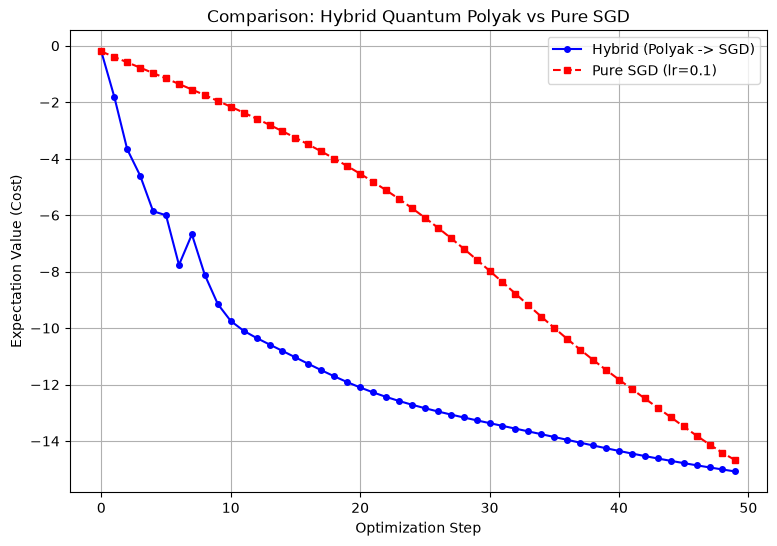

In [6]:
# --- 3. Plotting ---
plt.figure(figsize=(9, 6))
plt.plot(hybrid_costs, marker='o', markersize=4, linestyle='-', color='b', label='Hybrid (Polyak -> SGD)')
plt.plot(sgd_costs, marker='s', markersize=4, linestyle='--', color='r', label=f'Pure SGD (lr={fixed_lr})')
plt.xlabel("Optimization Step")
plt.ylabel("Expectation Value (Cost)")
plt.title("Comparison: Hybrid Quantum Polyak vs Pure SGD")
plt.legend()
plt.grid(True)
plt.show()

In [7]:
from scipy import stats

params_hybrid = init_params.copy()
energies_ours = []
prev_cost = np.inf

vs_ours = []
running_energy_estimate = []
running_spec_gap_estimate = []

is_temple = False
w_size = 10
print("--- Starting W T Run ---")
for step in range(50):
    cost = cost_fn(params_hybrid)
    energies_ours.append(cost)

    var = var_fn(params_hybrid)
    vs_ours.append(var)
    std = np.sqrt(var)
    grad = grad_fn(params_hybrid)
    grad_norm_sq = np.sum(grad**2)


    if step > w_size+1:
        # Perform linear regression
        slope, intercept, r_value, p_value, std_err = stats.linregress(vs_ours[-w_size:], energies_ours[-w_size:])
        running_energy_estimate.append(intercept)
        running_spec_gap_estimate.append(1/slope)
        # Calculate R-squared for goodness of fit
        r_squared = r_value**2

        if r_squared >= 0.7 and not is_temple:
            is_temple = True
            temple_step_when = step
            temple_step = 0.25 * slope

    else:
        running_energy_estimate.append(0)

    if step%10 == 0:
        print(f"Step {step:03d}: Cost = {cost:.6f} | temple = {is_temple}")


    lr = std / (grad_norm_sq + 1e-8)
    if is_temple:
        lr = temple_step

    params_hybrid = params_hybrid - lr * grad
    prev_cost = cost

--- Starting W T Run ---


Step 000: Cost = -0.203811 | temple = False


Step 010: Cost = -12.182530 | temple = False


Step 020: Cost = -14.395770 | temple = True


Step 030: Cost = -15.277203 | temple = True


Step 040: Cost = -15.790765 | temple = True


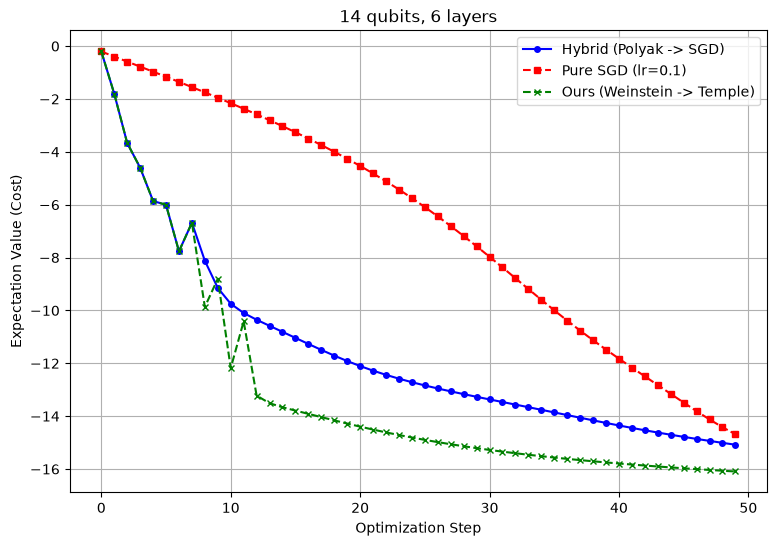

In [8]:
# --- 3. Plotting ---
plt.figure(figsize=(9, 6))
plt.plot(hybrid_costs, marker='o', markersize=4, linestyle='-', color='b', label='Hybrid (Polyak -> SGD)')
plt.plot(sgd_costs, marker='s', markersize=4, linestyle='--', color='r', label=f'Pure SGD (lr={fixed_lr})')
plt.plot(energies_ours, marker='x', markersize=4, linestyle='--', color='g', label='Ours (Weinstein -> Temple)')

plt.xlabel("Optimization Step")
plt.ylabel("Expectation Value (Cost)")
plt.title(f"{num_qubits} qubits, {num_layers} layers")
plt.legend()
plt.grid(True)
plt.show()

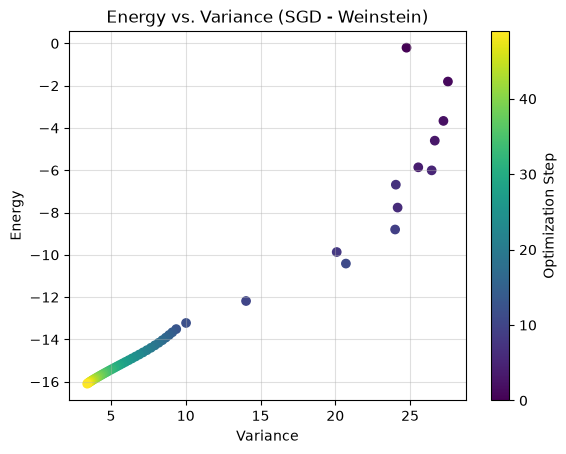

In [9]:
# fixed: y was hybrid_costs (energies of a DIFFERENT run); use this run's energies
plt.scatter(x=vs_ours, y=energies_ours, c=np.arange(len(vs_ours)), cmap='viridis')
plt.xlabel("Variance")
plt.ylabel("Energy")
plt.title("Energy vs. Variance (SGD - Weinstein)")
plt.colorbar(label="Optimization Step") # Add a color bar to show the step progression
plt.grid(alpha=0.4)

## Lenish extensions — literature-informed gap estimation and Temple switching

Everything below **builds on the cells above** (same `H`, `ansatz`, `cost_fn`, `var_fn`, `init_params`).
Three ideas from the literature are added and benchmarked against Parag's three runs:

1. **Exact reference by sparse Lanczos** (validation only): `scipy.sparse.linalg.eigsh` gives the true
   `E0, lambda_1, delta` even at 14 qubits, where dense `eigvalsh` is impossible.
2. **Min-rule schedule with a robust live regression gap** — the paper's two-phase schedule collapses to
   one line, `eta = min(sigma, sigma^2/delta_hat)/||grad||^2` (crossover is automatic and two-way);
   `delta_hat` comes from a Theil–Sen (robust) fit of E vs sigma^2 [zero-variance extrapolation:
   arXiv:2109.08132; Hubig et al., PRB 97, 045125], and overshoots fall back to the tuning-free
   Lipschitz step `1/L`, `L = sum|a_k|` [iCANS, arXiv:1909.09083; SPS_max cap, arXiv:2002.10542].
3. **PDS(2)/Lanczos moment estimator — windowless** — `<H>, <H^2>, <H^3>` define a 2x2 Krylov matrix
   whose eigenvalues estimate `(E0, lambda_1)` from the *current state alone* [CMX/PDS,
   arXiv:2101.08526; quantum computed moments, arXiv:2009.13140]. Neat identity: the resulting
   unexpanded-Temple numerator `sigma^2/(lam1_hat - E)` equals `E - E0_hat` — i.e. a **Polyak step
   with a measured f\*** (full derivations in `implementation.md`).

In [10]:
# --- Exact spectrum reference (VALIDATION ONLY -- the optimizers never see this) ---
# Dense eigvalsh at 14 qubits would need a 16384x16384 matrix; sparse Lanczos is instant.
from scipy.sparse.linalg import eigsh

Hs = H.sparse_matrix()                      # scipy CSR sparse matrix of H
lo = eigsh(Hs, k=2, which='SA', return_eigenvectors=False)
E0_exact, lam1_exact = float(min(lo)), float(max(lo))
delta_exact = lam1_exact - E0_exact
print(f"E0 = {E0_exact:.6f} | lambda_1 = {lam1_exact:.6f} | exact gap = {delta_exact:.6f}")

E0 = -17.471004 | lambda_1 = -17.254448 | exact gap = 0.216556


In [11]:
# --- Per-step gap estimate from Hamiltonian moments: PDS(2) / one Lanczos step ---
# <H>, <H^2>, <H^3> define the 2x2 Krylov (tridiagonal) matrix
#     T = [[a0, b], [b, a1]],   a0 = E,  b = sigma,  a1 = <(H-E)H(H-E)>/sigma^2.
# Its eigenvalues (e-, e+) estimate (E0, lambda_1) from the CURRENT state alone:
# no window, no history, no regression. e- <= E <= e+ always, and the estimate
# tightens as the state purifies. On hardware <H^2>,<H^3> are extra Pauli
# measurements (PDS/CMX arXiv:2101.08526, QCM arXiv:2009.13140); on the
# simulator we evaluate them with sparse mat-vecs on the statevector.

@qml.qnode(dev)
def state_fn(params):
    ansatz(params)
    return qml.state()

def moment_gap(params):
    psi = state_fn(params)
    Hpsi = Hs @ psi
    h1 = float(np.real(np.vdot(psi, Hpsi)))        # <H>
    h2 = float(np.real(np.vdot(Hpsi, Hpsi)))       # <H^2>
    h3 = float(np.real(np.vdot(Hpsi, Hs @ Hpsi)))  # <H^3>
    var = h2 - h1**2
    if var <= 1e-12:
        return h1, h1, 0.0                         # eigenstate: no gap info left
    a1 = (h3 - 2*h1*h2 + h1**3) / var
    mid = 0.5*(h1 + a1)
    rad = np.sqrt(0.25*(h1 - a1)**2 + var)
    return mid - rad, mid + rad, 2*rad             # E0_hat, lam1_hat, delta_hat

print("moment_gap at init:", tuple(round(x, 4) for x in moment_gap(init_params)))

moment_gap at init: (np.float64(-5.2341), np.float64(4.7186), np.float64(9.9526))


In [12]:
# --- Robust trajectory-regression gap estimator (upgraded Eq. 19) ---
# Same idea as cell 6's linregress, plus three upgrades from the extrapolation
# literature (arXiv:2109.08132): Theil-Sen robust slope (median of pairwise
# slopes -- one plateau spike cannot corrupt it), a positivity check, and the
# self-consistency check that the intercept (= E0_hat) sits below every energy
# actually observed. Returns None until the fit is trustworthy.

def regression_gap(vs, es, w, robust=True):
    if len(vs) < w:
        return None
    x, y = np.array(vs[-w:]), np.array(es[-w:])
    if robust:
        slope, intercept, _, _ = stats.theilslopes(y, x)
    else:
        slope, intercept, _, _, _ = stats.linregress(x, y)
    pred = intercept + slope * x
    ss_tot = float(np.sum((y - np.mean(y))**2))
    r2 = 1.0 - float(np.sum((y - pred)**2)) / max(ss_tot, 1e-12)
    if slope <= 0 or intercept > np.min(np.array(es)) or r2 < 0.7:
        return None                                # not trustworthy yet
    return float(intercept), float(1.0 / slope)    # E0_hat, delta_hat

In [13]:
# --- Run 4: min-rule schedule + robust live regression delta_hat ---
# The paper's two-phase schedule as ONE line:  sigma^2/delta < sigma  <=>  sigma < delta,
# so  eta = min(sigma, sigma^2/delta_hat) / ||grad||^2  IS the Weinstein->Temple
# crossover -- continuous, two-way, no switch flag, no frozen step. delta_hat keeps
# updating every step. Overshoot safeguard: one tuning-free Lipschitz step
# eta_L = 1/L with L = sum|a_k| (iCANS arXiv:1909.09083) instead of a hand-tuned lr,
# in the spirit of the SPS_max cap (arXiv:2002.10542).

L_lip = float(np.sum(np.abs(np.array(coeffs))))
eta_L = 1.0 / L_lip
print(f"Lipschitz bound L = sum|a_k| = {L_lip:.0f} -> fallback step 1/L = {eta_L:.4f}")

params_min = init_params.copy()
energies_min, vs_min, lrs_min, gaps_min = [], [], [], []
prev_cost = np.inf

print("--- Starting Min-rule Run (regression delta_hat) ---")
for step in range(50):
    cost = cost_fn(params_min)
    energies_min.append(cost)
    var = var_fn(params_min)
    vs_min.append(var)
    std = np.sqrt(var)
    grad = grad_fn(params_min)
    grad_norm_sq = np.sum(grad**2)

    fit = regression_gap(vs_min, energies_min, w_size)      # None until trusted
    delta_hat = fit[1] if fit else None
    gaps_min.append(delta_hat if delta_hat is not None else np.nan)

    if delta_hat is None:
        num, tag = std, "weinstein"                         # Eq. 18a
    else:
        num = min(std, var / delta_hat)                     # the min-rule crossover
        tag = "temple" if var / delta_hat < std else "weinstein"
    lr = num / (grad_norm_sq + 1e-8)
    if cost > prev_cost:                                    # overshoot -> safe step
        lr, tag = eta_L, "lipschitz"
    lrs_min.append(float(lr))

    if step % 10 == 0:
        print(f"Step {step:03d}: Cost = {cost:.6f} | {tag} | lr = {lr:.4f}")
    params_min = params_min - lr * grad
    prev_cost = cost

print(f"Final energy (min-rule) = {energies_min[-1]:.6f}")

Lipschitz bound L = sum|a_k| = 27 -> fallback step 1/L = 0.0370
--- Starting Min-rule Run (regression delta_hat) ---


Step 000: Cost = -0.203811 | weinstein | lr = 2.5736


Step 010: Cost = -8.711708 | lipschitz | lr = 0.0370


Step 020: Cost = -10.722608 | weinstein | lr = 0.1471


Step 030: Cost = -15.451140 | weinstein | lr = 0.4917


Step 040: Cost = -15.899479 | temple | lr = 0.1890


Final energy (min-rule) = -16.088220


In [14]:
# --- Run 5: PDS(2) windowless delta_hat + unexpanded Temple bound ---
# Gap and first-excited estimates come from the CURRENT state's moments (cell 11).
# Numerator: Temple's original, unexpanded form sigma^2/(lam1_hat - E) whenever
# E < lam1_hat (the validity condition IS the switch; Temple 1928), min'd with
# Weinstein's sigma. Identity worth knowing: for the 2x2 Krylov matrix,
# (E - e-)(e+ - E) = sigma^2 exactly, so sigma^2/(lam1_hat - E) = E - E0_hat:
# this run is literally a Polyak step with a MEASURED estimate of f*.

params_pds = init_params.copy()
energies_pds, vs_pds, lrs_pds, gaps_pds = [], [], [], []
prev_cost = np.inf

print("--- Starting PDS(2) Moment Run ---")
for step in range(50):
    cost = cost_fn(params_pds)
    energies_pds.append(cost)
    var = var_fn(params_pds)
    vs_pds.append(var)
    std = np.sqrt(var)
    grad = grad_fn(params_pds)
    grad_norm_sq = np.sum(grad**2)

    E0_hat, lam1_hat, delta_hat = moment_gap(params_pds)
    gaps_pds.append(delta_hat)

    num = std                                              # Weinstein default
    if cost < lam1_hat:                                    # Temple valid (w.r.t. estimate)
        num = min(std, var / (lam1_hat - cost))            # = min(sigma, E - E0_hat)
    lr = num / (grad_norm_sq + 1e-8)
    if cost > prev_cost:                                   # overshoot -> safe step
        lr = eta_L

    lrs_pds.append(float(lr))
    if step % 10 == 0:
        print(f"Step {step:03d}: Cost = {cost:.6f} | delta_hat = {delta_hat:.3f} | lr = {lr:.4f}")
    params_pds = params_pds - lr * grad
    prev_cost = cost

print(f"Final energy (PDS2) = {energies_pds[-1]:.6f}")

--- Starting PDS(2) Moment Run ---


Step 000: Cost = -0.203811 | delta_hat = 9.953 | lr = 2.5736


Step 010: Cost = -8.662729 | delta_hat = 9.266 | lr = 0.0370


Step 020: Cost = -14.190616 | delta_hat = 9.135 | lr = 0.1333


Step 030: Cost = -15.823976 | delta_hat = 6.335 | lr = 0.4762


Step 040: Cost = -12.312959 | delta_hat = 15.826 | lr = 0.0370


Final energy (PDS2) = -15.318177


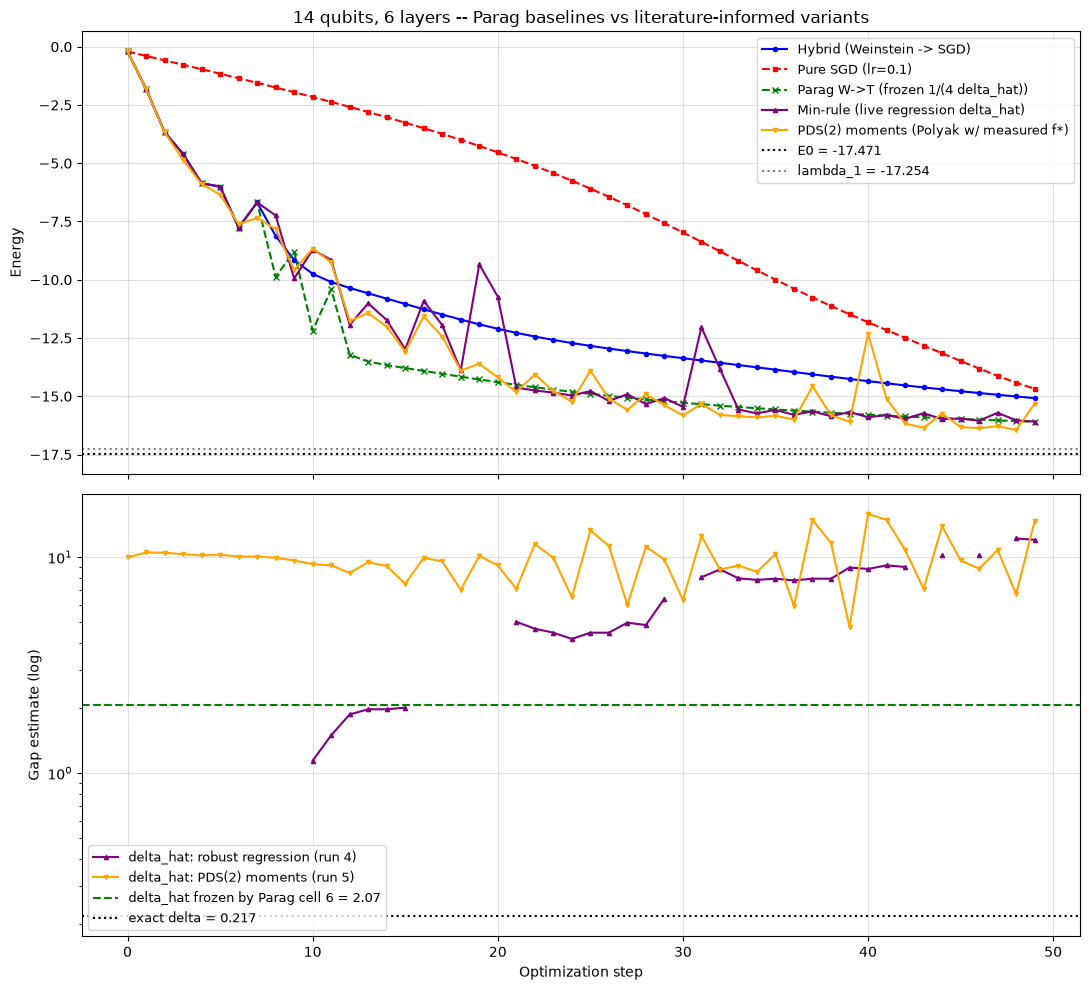

In [ ]:
# --- Comparison plots: all five runs + gap-estimate quality ---
fig, axs = plt.subplots(2, 1, figsize=(11, 10), sharex=True)

axs[0].plot(hybrid_costs, 'o-', color='b', markersize=3, label='Hybrid (Weinstein -> SGD)')
axs[0].plot(sgd_costs, 's--', color='r', markersize=3, label=f'Pure SGD (lr={fixed_lr})')
axs[0].plot(energies_ours, 'x--', color='g', markersize=4, label='Parag W->T (frozen 1/(4 delta_hat))')
axs[0].plot(energies_min, '^-', color='purple', markersize=3, label='Min-rule (live regression delta_hat)')
axs[0].plot(energies_pds, 'v-', color='orange', markersize=3, label='PDS(2) moments (Polyak w/ measured f*)')
axs[0].axhline(E0_exact, color='k', linestyle=':', label=f'E0 = {E0_exact:.3f}')
axs[0].axhline(lam1_exact, color='gray', linestyle=':', label=f'lambda_1 = {lam1_exact:.3f}')
axs[0].set_ylabel("Energy")
axs[0].set_title(f"{num_qubits} qubits, {num_layers} layers -- Parag baselines vs literature-informed variants")
axs[0].legend(fontsize=9)
axs[0].grid(alpha=0.4)

# axs[1].plot(gaps_min, '^-', color='purple', markersize=3, label='delta_hat: robust regression (run 4)')
# axs[1].plot(gaps_pds, 'v-', color='orange', markersize=3, label='delta_hat: PDS(2) moments (run 5)')
# if 'temple_step' in dir():
#     axs[1].axhline(0.25/temple_step, color='g', linestyle='--',
#                    label=f'delta_hat frozen by Parag cell 6 = {0.25/temple_step:.2f}')
# axs[1].axhline(delta_exact, color='k', linestyle=':', label=f'exact delta = {delta_exact:.3f}')
# axs[1].set_yscale('log')
# axs[1].set_xlabel("Optimization step")
# axs[1].set_ylabel("Gap estimate (log)")
# axs[1].legend(fontsize=9)
# axs[1].grid(alpha=0.4)

plt.tight_layout()
plt.savefig("lenish_wt_comparison.png", dpi=150)
plt.show()

In [16]:
# --- Summary table ---
print(f"Exact E0                          : {E0_exact:.6f}   (gap delta = {delta_exact:.4f})")
print(f"Hybrid (Weinstein->SGD)  final E  : {hybrid_costs[-1]:.6f}")
print(f"Pure SGD                 final E  : {sgd_costs[-1]:.6f}")
print(f"Parag W->T               final E  : {energies_ours[-1]:.6f}")
print(f"Min-rule (regression)    final E  : {energies_min[-1]:.6f}")
print(f"PDS(2) moments           final E  : {energies_pds[-1]:.6f}")
import math as _m
last_reg = next((g for g in reversed(gaps_min) if not _m.isnan(g)), None)
if last_reg is not None:
    print(f"delta_hat regression (last valid) : {last_reg:.4f}  ({last_reg/delta_exact:.1f}x exact)")
print(f"delta_hat PDS(2) (final)          : {gaps_pds[-1]:.4f}  ({gaps_pds[-1]/delta_exact:.1f}x exact)")

Exact E0                          : -17.471004   (gap delta = 0.2166)
Hybrid (Weinstein->SGD)  final E  : -15.080067
Pure SGD                 final E  : -14.682589
Parag W->T               final E  : -16.092907
Min-rule (regression)    final E  : -16.088220
PDS(2) moments           final E  : -15.318177
delta_hat regression (last valid) : 12.0123  (55.5x exact)
delta_hat PDS(2) (final)          : 14.6850  (67.8x exact)
